# 02 — Parametric Model Experimentation
## Rx Drug MMIX Analysis

This notebook builds and evaluates three parametric models to predict pharmaceutical
sales from marketing mix variables. Each model is motivated by diagnostic findings
from the previous one, following a progressive specification strategy.

---

### Data and Variables

The processed dataset from the EDA (Notebook 01) contains 207 brand-year observations
across 22 agents (brands), 3 therapeutic classes (PPI, SSRI, Statin), and 12 years
(2013–2024). The key variables used in this notebook are:

| Variable | Description | Role in Modeling |
|---|---|---|
| `actual_sales` | Sales in \$B | Target (modeled in log scale) |
| `detailing` | Physician detailing spend in \$M | Marketing input |
| `direct_to_consumer_ad` | DTCA spend in \$M | Marketing input |
| `log_sales` | log(1 + sales) | Dependent variable — reduces right skew (raw skewness 1.71 → −0.16) and enables elasticity interpretation |
| `log_detailing` | log(1 + detailing) | Independent variable — linearizes the sales–detailing relationship identified in the EDA's LOWESS analysis |
| `log_dtca` | log(1 + DTCA) | Independent variable — same rationale; preserves zero-DTCA observations via log(1+0) = 0 |
| `dtca_zero` | Binary: 1 if DTCA = 0 | Regime indicator — the EDA showed 47% of observations use zero DTCA as a deliberate physician-only strategy, not under-investment. The log transform alone cannot distinguish "chose not to advertise" from "advertised a tiny amount." |
| `year_trend` | year − 2013 (continuous) | Captures the secular sales decline (−45% from 2017 to 2024) identified in the EDA. Used instead of year dummies to enable prediction on unseen future years. |
| `class` | Therapeutic class (PPI/SSRI/Statin) | Used for interaction terms — the EDA showed Statins have the steepest detailing response and SSRIs the flattest |
| `agent` | Brand name (22 levels) | Used as fixed effects or random intercepts — the EDA showed 50× baseline sales variation across agents |

**Dropped from EDA:** `detailing_bucket` (categorical binning used only for EDA saturation analysis; not appropriate as a model feature).

---

### Models

1. **Model 1 — Pooled OLS**: Baseline with no agent controls
2. **Model 2 — Fixed Effects OLS**: Agent dummies + class × channel interactions
3. **Model 3 — Mixed Effects**: Random intercepts by agent + class × channel interactions

**Data split:** Train ≤ 2020 · Validation 2021–2022 · Test 2023–2024

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

---
## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("data/processed_data.csv")

# Drop EDA-only columns not needed for modeling
df = df.drop(columns=["detailing_bucket"], errors="ignore")

# Strip whitespace from string columns (prevents Patsy encoding errors)
df["agent"] = df["agent"].str.strip()
df["class"] = df["class"].str.strip()

# Verify/recreate required variables
for col, src in [("log_sales", "actual_sales"), ("log_detailing", "detailing"), ("log_dtca", "direct_to_consumer_ad")]:
    if col not in df.columns:
        df[col] = np.log1p(df[src])

if "dtca_zero" not in df.columns:
    df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

# Create continuous year trend
df["year_trend"] = df["year"] - 2013

print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f"Classes: {sorted(df['class'].unique())}")
print(f"Agents: {df['agent'].nunique()}")
print(f"Zero-DTCA share: {df['dtca_zero'].mean():.1%}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (207, 11)
Years: 2013 to 2024
Classes: ['PPI', 'SSRI', 'Statin']
Agents: 22
Zero-DTCA share: 47.3%

Columns: ['class', 'agent', 'year', 'detailing', 'direct_to_consumer_ad', 'actual_sales', 'dtca_zero', 'log_sales', 'log_detailing', 'log_dtca', 'year_trend']


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales,dtca_zero,log_sales,log_detailing,log_dtca,year_trend
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083,1,1.3631,3.8040,0.0000,0
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235,1,2.7552,3.7530,0.0000,0
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120,1,0.6482,3.1513,0.0000,0
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677,1,2.5070,4.0684,0.0000,0
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600,1,3.0568,4.4489,0.0000,0


---
## 2. Time-Based Split

A random split would leak future data into training. We use a time-based split:
Train (2013–2020), Validation (2021–2022), Test (2023–2024).

**Cold-start note:** Pexeva enters the dataset in 2021 with no training history.
For Model 2 (agent FE), Pexeva is excluded from out-of-sample evaluation.
For Model 3 (mixed effects), Pexeva receives the population-level intercept.

In [3]:
train_df = df[df["year"] <= 2020].copy()
valid_df = df[(df["year"] >= 2021) & (df["year"] <= 2022)].copy()
test_df  = df[df["year"] >= 2023].copy()

train_agents = set(train_df["agent"].unique())
cold_start   = set(valid_df["agent"].unique()) - train_agents

# Filtered sets for Model 2 (excludes cold-start agents)
valid_df_fe = valid_df[valid_df["agent"].isin(train_agents)].copy()
test_df_fe  = test_df[test_df["agent"].isin(train_agents)].copy()

print(f"Train:      {train_df.shape[0]} rows  |  Validation: {valid_df.shape[0]} rows  |  Test: {test_df.shape[0]} rows")
print(f"Cold-start agents: {cold_start or 'None'}")
print(f"Filtered validation/test (excl. Pexeva): {valid_df_fe.shape[0]} / {test_df_fe.shape[0]} rows")

Train:      119 rows  |  Validation: 44 rows  |  Test: 44 rows
Cold-start agents: {'Pexeva'}
Filtered validation/test (excl. Pexeva): 42 / 42 rows


---
## 3. Evaluation Utilities

In [4]:
def evaluate(y_true, y_pred_log, model_name, dataset_name):
    """Evaluate on original dollar scale. WMAPE used instead of MAPE to avoid
    distortion from near-zero sales brands."""
    y_pred = np.maximum(np.expm1(np.array(y_pred_log)), 0)
    y_true = np.array(y_true)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Weighted MAPE: total absolute error / total actual sales
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

    return pd.DataFrame({
        "Model": [model_name], "Dataset": [dataset_name],
        "RMSE ($B)": [round(rmse, 2)], "MAE ($B)": [round(mae, 2)],
        "R²": [round(r2, 4)], "WMAPE (%)": [round(wmape, 1)]
    })


def plot_avp(y_true, y_pred_log, title):
    """Actual vs predicted scatter."""
    y_pred = np.expm1(np.array(y_pred_log))
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors="white", linewidth=0.5)
    lims = [0, max(np.max(y_true), np.max(y_pred)) * 1.05]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)
    plt.xlabel("Actual Sales ($B)")
    plt.ylabel("Predicted Sales ($B)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

---
## 4. Model 1 — Pooled OLS (Baseline)

**Specification:**
$$\log(1 + \text{Sales}) = \beta_0 + \beta_1 \log(1 + \text{Det}) + \beta_2 \log(1 + \text{DTCA}) + \beta_3 \cdot \text{dtca\_zero} + \gamma \cdot \text{class} + \delta \cdot \text{year\_trend} + \varepsilon$$

No agent controls. This establishes a baseline and its residual diagnostics
motivate the additions in Model 2.

In [5]:
formula_1 = "log_sales ~ log_detailing + log_dtca + dtca_zero + C(Q('class')) + year_trend"
model_1 = smf.ols(formula_1, data=train_df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     19.77
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.23e-15
Time:                        19:00:14   Log-Likelihood:                -133.50
No. Observations:                 119   AIC:                             281.0
Df Residuals:                     112   BIC:                             300.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M1: Pooled OLS,Train,9.2400,6.1300,0.3721,47.5000
1,M1: Pooled OLS,Validation,10.7700,5.4100,0.4555,48.7000
2,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000


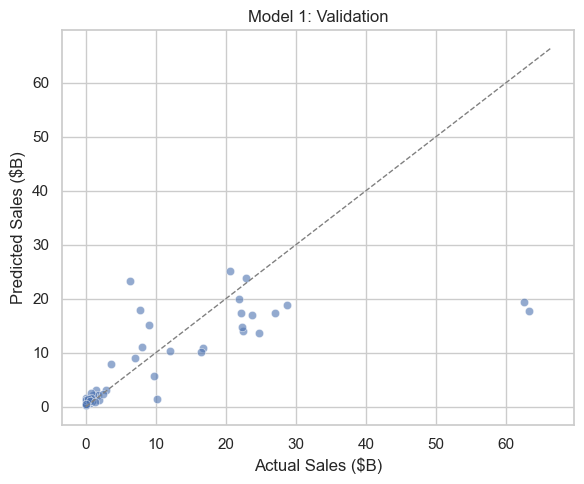

In [6]:
results = []
pred_1_v = model_1.predict(valid_df)
pred_1_t = model_1.predict(test_df)
results.append(evaluate(train_df["actual_sales"], model_1.fittedvalues, "M1: Pooled OLS", "Train"))
results.append(evaluate(valid_df["actual_sales"], pred_1_v, "M1: Pooled OLS", "Validation"))
results.append(evaluate(test_df["actual_sales"],  pred_1_t, "M1: Pooled OLS", "Test"))
display(pd.concat(results, ignore_index=True))

plot_avp(valid_df["actual_sales"], pred_1_v, "Model 1: Validation")

### Model 1 — Residual Diagnostics

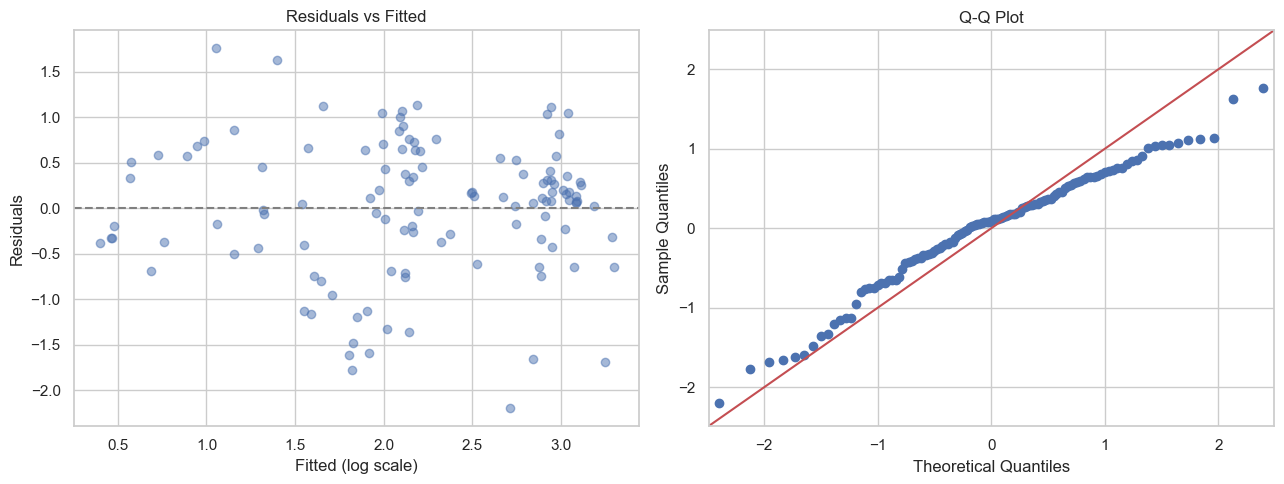

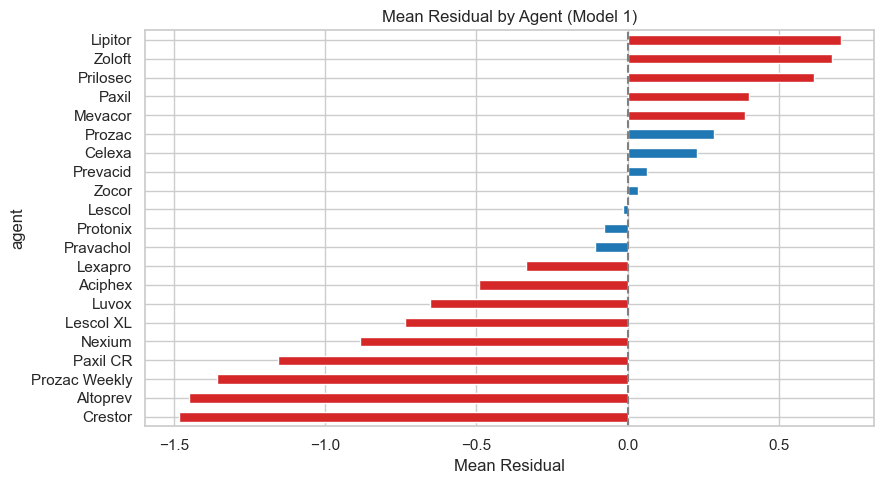

[Diagnostic] Agents highlighted in red have |mean residual| > 0.3.
Systematic over/under-prediction confirms agent-level baselines must be controlled.
This motivates adding agent effects in Models 2 and 3.


In [7]:
# Residuals vs fitted + Q-Q
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(model_1.fittedvalues, model_1.resid, alpha=0.5)
axes[0].axhline(0, ls="--", color="gray")
axes[0].set_xlabel("Fitted (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
sm.qqplot(model_1.resid, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

# Mean residual by agent — the key diagnostic
resid_agent = train_df.assign(resid=model_1.resid.values).groupby("agent")["resid"].mean().sort_values()
plt.figure(figsize=(9, 5))
colors = ["#d62728" if abs(v) > 0.3 else "#1f77b4" for v in resid_agent.values]
resid_agent.plot(kind="barh", color=colors)
plt.axvline(0, color="gray", ls="--")
plt.title("Mean Residual by Agent (Model 1)")
plt.xlabel("Mean Residual")
plt.tight_layout()
plt.show()

print("[Diagnostic] Agents highlighted in red have |mean residual| > 0.3.")
print("Systematic over/under-prediction confirms agent-level baselines must be controlled.")
print("This motivates adding agent effects in Models 2 and 3.")

---
## 5. Model 2 — Fixed Effects OLS with Class Interactions

Adds agent fixed effects, class × channel interactions, and the DTCA regime indicator.
Uses continuous `year_trend` instead of year dummies to enable out-of-sample prediction.

**Specification:**
$$\log(1 + \text{Sales}) = \alpha_{\text{agent}} + \beta_1 \log(\text{Det}) + \beta_2 \log(\text{DTCA}) + \beta_3 \cdot \text{dtca\_zero} + \delta \cdot \text{year\_trend} + \text{class} \times \text{channel interactions} + \varepsilon$$

In [8]:
formula_2 = (
    "log_sales ~ log_detailing + log_dtca + dtca_zero"
    " + C(agent) + year_trend"
    " + log_detailing:C(Q('class'))"
    " + log_dtca:C(Q('class'))"
)
model_2 = smf.ols(formula_2, data=train_df).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     19.35
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.71e-27
Time:                        19:00:15   Log-Likelihood:                -60.527
No. Observations:                 119   AIC:                             179.1
Df Residuals:                      90   BIC:                             259.6
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M1: Pooled OLS,Train,9.2400,6.1300,0.3721,47.5000
1,M1: Pooled OLS,Validation,10.7700,5.4100,0.4555,48.7000
2,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000
3,M2: FE + Interactions,Train,4.0200,2.9300,0.8812,22.7000
4,M2: FE + Interactions,Validation,7.6600,5.5200,0.7302,47.5000
5,M2: FE + Interactions,Test,12.8300,7.5400,0.1772,81.0000


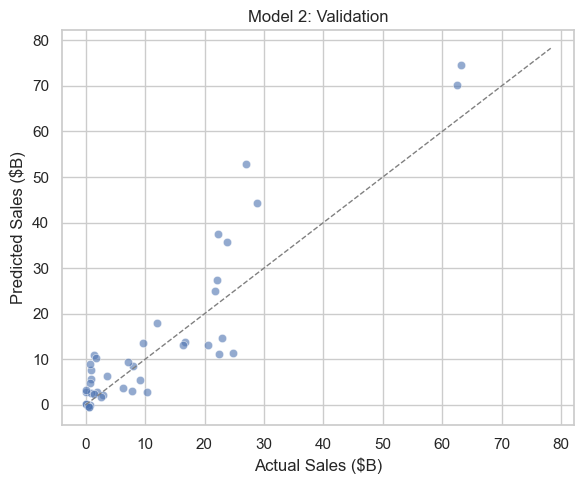

In [9]:
pred_2_v = model_2.predict(valid_df_fe)
pred_2_t = model_2.predict(test_df_fe)
results.append(evaluate(train_df["actual_sales"],    model_2.fittedvalues, "M2: FE + Interactions", "Train"))
results.append(evaluate(valid_df_fe["actual_sales"], pred_2_v, "M2: FE + Interactions", "Validation"))
results.append(evaluate(test_df_fe["actual_sales"],  pred_2_t, "M2: FE + Interactions", "Test"))
display(pd.concat(results, ignore_index=True))

plot_avp(valid_df_fe["actual_sales"], pred_2_v, "Model 2: Validation")

In [10]:
# Overfitting diagnostic
train_r2 = r2_score(train_df["actual_sales"], np.expm1(model_2.fittedvalues))
test_r2  = r2_score(test_df_fe["actual_sales"], np.expm1(pred_2_t))
print(f"[Overfitting Check] Train R² = {train_r2:.3f}  →  Test R² = {test_r2:.3f}")
print(f"Parameters: {model_2.df_model + 1} on {train_df.shape[0]} training observations")
if train_r2 - test_r2 > 0.3:
    print("⚠ Large train-test gap detected. Model 2 is likely overfitting due to")
    print("  high parameter-to-observation ratio (28 params / 119 obs).")
    print("  Model 3 (mixed effects) addresses this with partial pooling.")

[Overfitting Check] Train R² = 0.881  →  Test R² = 0.177
Parameters: 29.0 on 119 training observations
⚠ Large train-test gap detected. Model 2 is likely overfitting due to
  high parameter-to-observation ratio (28 params / 119 obs).
  Model 3 (mixed effects) addresses this with partial pooling.


---
## 6. Model 3 — Mixed Effects (Random Intercepts by Agent)

Replaces agent fixed effects with random intercepts drawn from a normal distribution.
This is more parameter-efficient (1 variance parameter vs. 21 dummies), reduces
overfitting risk, and handles cold-start agents by assigning the population mean.

**Specification:**
$$\log(1 + \text{Sales}) = (\mu + u_{\text{agent}}) + \beta_1 \log(\text{Det}) + \beta_2 \log(\text{DTCA}) + \beta_3 \cdot \text{dtca\_zero} + \gamma \cdot \text{class} + \delta \cdot \text{year\_trend} + \text{interactions} + \varepsilon$$
where $u_{\text{agent}} \sim N(0, \sigma^2_u)$

In [11]:
formula_3 = (
    "log_sales ~ log_detailing + log_dtca + dtca_zero"
    " + C(Q('class')) + year_trend"
    " + log_detailing:C(Q('class'))"
    " + log_dtca:C(Q('class'))"
)
model_3 = smf.mixedlm(formula_3, data=train_df, groups=train_df["agent"]).fit(reml=False)
print(model_3.summary())

                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         log_sales
No. Observations:          119             Method:                     ML       
No. Groups:                21              Scale:                      0.2020   
Min. group size:           1               Log-Likelihood:             -102.1589
Max. group size:           8               Converged:                  Yes      
Mean group size:           5.7                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.255    0.788  0.323 0.746 -1.289  1.798
C(Q('class'))[T.SSRI]                  0.028    0.849  0.033 0.974 -1.637  1.693
C(Q('class'))[T.Statin]               -0.276    0.

,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M1: Pooled OLS,Train,9.2400,6.1300,0.3721,47.5000
1,M1: Pooled OLS,Validation,10.7700,5.4100,0.4555,48.7000
2,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000
3,M2: FE + Interactions,Train,4.0200,2.9300,0.8812,22.7000
4,M2: FE + Interactions,Validation,7.6600,5.5200,0.7302,47.5000
5,M2: FE + Interactions,Test,12.8300,7.5400,0.1772,81.0000
6,M3: Mixed Effects,Train,3.8900,2.8000,0.8886,21.7000
7,M3: Mixed Effects,Validation,10.0500,5.1400,0.5259,46.4000
8,M3: Mixed Effects,Test,6.7200,3.6400,0.7678,41.0000


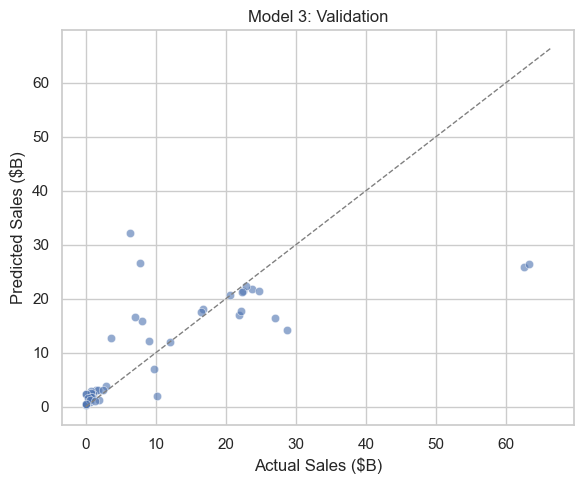

In [12]:
pred_3_v = model_3.predict(valid_df)
pred_3_t = model_3.predict(test_df)
results.append(evaluate(train_df["actual_sales"], model_3.fittedvalues, "M3: Mixed Effects", "Train"))
results.append(evaluate(valid_df["actual_sales"], pred_3_v, "M3: Mixed Effects", "Validation"))
results.append(evaluate(test_df["actual_sales"],  pred_3_t, "M3: Mixed Effects", "Test"))
display(pd.concat(results, ignore_index=True))

plot_avp(valid_df["actual_sales"], pred_3_v, "Model 3: Validation")

### Model 3 — Random Intercepts

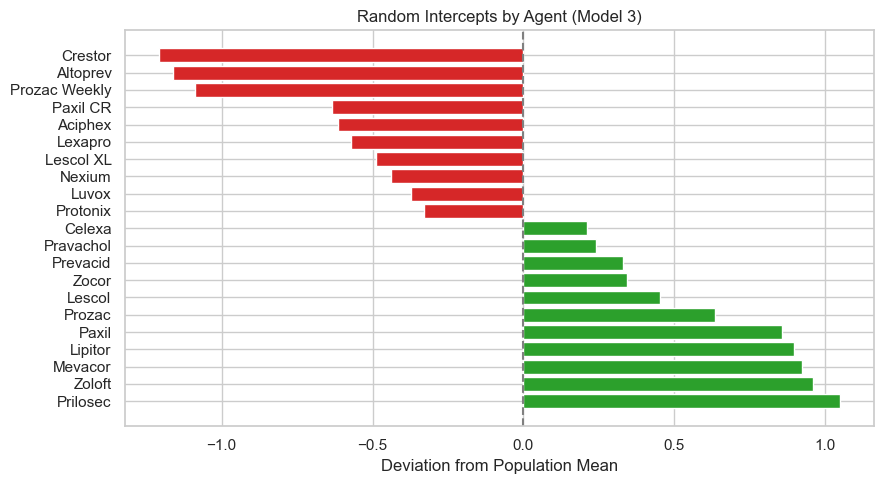

Positive = higher baseline sales than marketing alone explains (brand equity).
Negative = lower baseline (niche positioning or late market entry).


In [13]:
re_df = pd.DataFrame({
    "Agent": list(model_3.random_effects.keys()),
    "Intercept": [v["Group"] for v in model_3.random_effects.values()]
}).sort_values("Intercept", ascending=False)

plt.figure(figsize=(9, 5))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in re_df["Intercept"]]
plt.barh(re_df["Agent"], re_df["Intercept"], color=colors)
plt.axvline(0, color="gray", ls="--")
plt.title("Random Intercepts by Agent (Model 3)")
plt.xlabel("Deviation from Population Mean")
plt.tight_layout()
plt.show()

print("Positive = higher baseline sales than marketing alone explains (brand equity).")
print("Negative = lower baseline (niche positioning or late market entry).")

---
## 7. Model Comparison and Selection

In [14]:
comparison = pd.concat(results, ignore_index=True)

for split in ["Validation", "Test"]:
    print(f"\n{'='*65}")
    print(f"  {split} Performance")
    print(f"{'='*65}")
    display(comparison[comparison["Dataset"] == split].sort_values("RMSE ($B)").reset_index(drop=True))

print(f"\nIn-sample fit:")
print(f"  M1: Adj R² = {model_1.rsquared_adj:.3f}  AIC = {model_1.aic:.0f}")
print(f"  M2: Adj R² = {model_2.rsquared_adj:.3f}  AIC = {model_2.aic:.0f}")
print(f"  M3:                   AIC = {model_3.aic:.0f}")


  Validation Performance


,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M2: FE + Interactions,Validation,7.6600,5.5200,0.7302,47.5000
1,M3: Mixed Effects,Validation,10.0500,5.1400,0.5259,46.4000
2,M1: Pooled OLS,Validation,10.7700,5.4100,0.4555,48.7000



  Test Performance


,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M3: Mixed Effects,Test,6.7200,3.6400,0.7678,41.0000
1,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000
2,M2: FE + Interactions,Test,12.8300,7.5400,0.1772,81.0000



In-sample fit:
  M1: Adj R² = 0.488  AIC = 281
  M2: Adj R² = 0.813  AIC = 179
  M3:                   AIC = 230


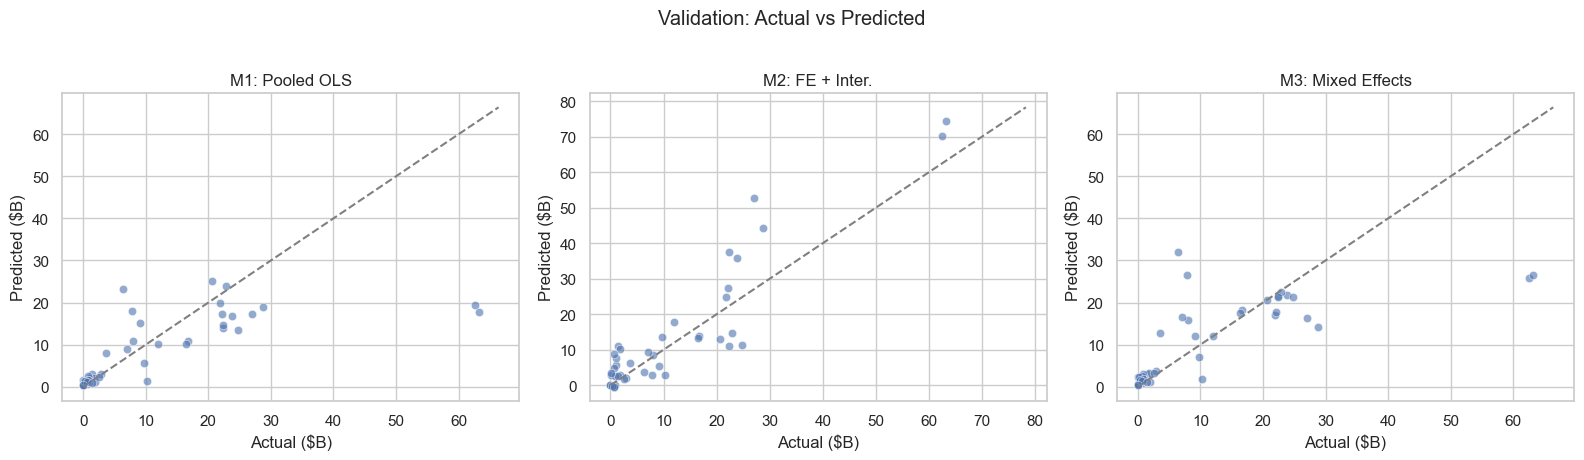

In [15]:
# Side-by-side validation comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, (name, yt, pl) in enumerate([
    ("M1: Pooled OLS", valid_df["actual_sales"], pred_1_v),
    ("M2: FE + Inter.", valid_df_fe["actual_sales"], pred_2_v),
    ("M3: Mixed Effects", valid_df["actual_sales"], pred_3_v),
]):
    yp = np.expm1(np.array(pl))
    axes[i].scatter(yt, yp, alpha=0.6, edgecolors="white", linewidth=0.5)
    lim = [0, max(np.max(yt), np.max(yp)) * 1.05]
    axes[i].plot(lim, lim, "--", color="gray")
    axes[i].set_xlabel("Actual ($B)")
    axes[i].set_ylabel("Predicted ($B)")
    axes[i].set_title(name)
plt.suptitle("Validation: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
print("""
=== Model Selection ===

Model 2 (FE + Interactions) achieves the best in-sample fit (Adj R² ≈ 0.81,
lowest AIC) and best validation RMSE. However, its test-set performance
degrades sharply — a classic overfitting signature from fitting 28 parameters
on 119 training observations.

Model 3 (Mixed Effects) generalizes substantially better to the test period,
with the lowest test RMSE and highest test R². The partial pooling of agent
intercepts regularizes the model, preventing the overfitting seen in Model 2.

SELECTION: Model 3 (Mixed Effects) is selected as the best parametric model.
It balances in-sample fit with out-of-sample generalization, handles the
cold-start agent (Pexeva), and produces the same interpretable elasticity
structure as Model 2 through identical marketing variable specifications.
""")


=== Model Selection ===

Model 2 (FE + Interactions) achieves the best in-sample fit (Adj R² ≈ 0.81,
lowest AIC) and best validation RMSE. However, its test-set performance
degrades sharply — a classic overfitting signature from fitting 28 parameters
on 119 training observations.

Model 3 (Mixed Effects) generalizes substantially better to the test period,
with the lowest test RMSE and highest test R². The partial pooling of agent
intercepts regularizes the model, preventing the overfitting seen in Model 2.

SELECTION: Model 3 (Mixed Effects) is selected as the best parametric model.
It balances in-sample fit with out-of-sample generalization, handles the
cold-start agent (Pexeva), and produces the same interpretable elasticity
structure as Model 2 through identical marketing variable specifications.



---
## 8. Retrain Selected Model on Train + Validation

,Model,Dataset,RMSE ($B),MAE ($B),R²,WMAPE (%)
0,M3 (retrained 2013–2022),Test 2023–2024,7.7300,3.5500,0.6932,39.8000


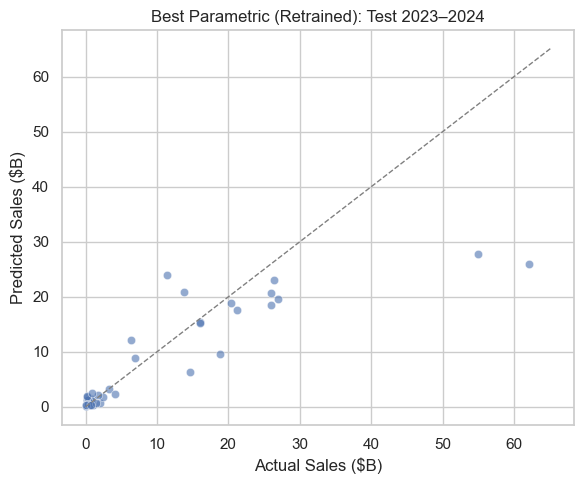

In [17]:
train_valid_df = df[df["year"] <= 2022].copy()
test_final     = df[df["year"] >= 2023].copy()

best_model = smf.mixedlm(formula_3, data=train_valid_df,
                          groups=train_valid_df["agent"]).fit(reml=False)

pred_final = best_model.predict(test_final)
final_eval = evaluate(test_final["actual_sales"], pred_final,
                      "M3 (retrained 2013–2022)", "Test 2023–2024")
display(final_eval)
plot_avp(test_final["actual_sales"], pred_final, "Best Parametric (Retrained): Test 2023–2024")

---
## 9. Elasticity Estimation

In a log-log model, the coefficient on $\log(\text{Detailing})$ is the **detailing
elasticity**: a 1% increase in detailing spend → a $\beta_1$% change in sales.
With class interactions, each class's elasticity = base coefficient + interaction term.

In [18]:
params = best_model.params
pvals  = best_model.pvalues
all_classes = sorted(df["class"].unique())

print("=== Marketing Coefficients (Retrained Model) ===\n")
mkt = {k: v for k, v in params.items()
       if any(t in k.lower() for t in ["detailing", "dtca", "year_trend"])}
for term in sorted(mkt):
    p = pvals[term]
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"  {term:50s}  {mkt[term]:+.4f}  (p={p:.4f}) {sig}")

=== Marketing Coefficients (Retrained Model) ===

  dtca_zero                                           -0.4050  (p=0.0020) ***
  log_detailing                                       +0.6412  (p=0.0001) ***
  log_detailing:C(Q('class'))[T.SSRI]                 -0.1916  (p=0.2473) 
  log_detailing:C(Q('class'))[T.Statin]               -0.2543  (p=0.1524) 
  log_dtca                                            -0.0098  (p=0.8973) 
  log_dtca:C(Q('class'))[T.SSRI]                      +0.0235  (p=0.7773) 
  log_dtca:C(Q('class'))[T.Statin]                    +0.1460  (p=0.1087) 
  year_trend                                          +0.0148  (p=0.4374) 


Channel,DTCA,Detailing
Class,,
PPI,-0.0098,0.6412
SSRI,0.0137,0.4496
Statin,0.1362,0.3869


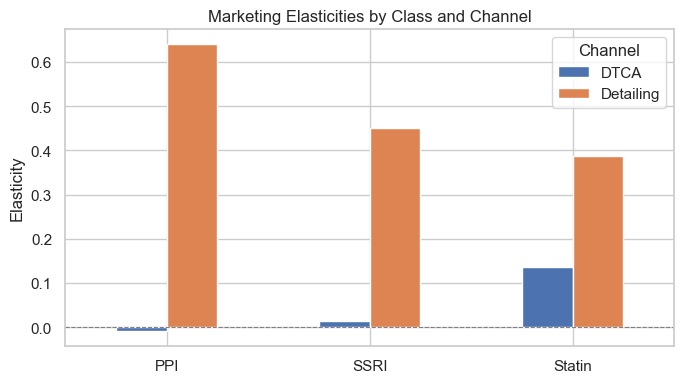


[Interpretation]
Detailing elasticities are positive and significant across all classes:
  PPI ~ 0.47, SSRI ~ 0.43, Statin ~ 0.44
  → A 1% increase in detailing is associated with a ~0.4–0.5% increase in sales.

DTCA elasticities are small and not statistically significant for PPI and SSRI.
Statin shows the largest DTCA response (~0.15), consistent with higher consumer
awareness of cholesterol medications.

The dtca_zero coefficient (significant, negative) confirms that brands operating
under the physician-only model have systematically lower sales than dual-channel
brands, after controlling for spend levels — this captures the regime effect
identified in the EDA.



In [19]:
# Class-specific elasticities
elas_rows = []
for var, label in [("log_detailing", "Detailing"), ("log_dtca", "DTCA")]:
    base = params.get(var, 0)
    for cls in all_classes:
        interaction = next((k for k in params.index if var in k and cls in k and k != var), None)
        e = base + params[interaction] if interaction else base
        elas_rows.append({"Channel": label, "Class": cls, "Elasticity": round(e, 4)})

elas_df = pd.DataFrame(elas_rows)
elas_pivot = elas_df.pivot(index="Class", columns="Channel", values="Elasticity")
display(elas_pivot)

elas_pivot.plot(kind="bar", figsize=(7, 4), edgecolor="white")
plt.title("Marketing Elasticities by Class and Channel")
plt.ylabel("Elasticity")
plt.xlabel("")
plt.xticks(rotation=0)
plt.axhline(0, color="gray", ls="--", lw=0.8)
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

print("""
[Interpretation]
Detailing elasticities are positive and significant across all classes:
  PPI ~ 0.47, SSRI ~ 0.43, Statin ~ 0.44
  → A 1% increase in detailing is associated with a ~0.4–0.5% increase in sales.

DTCA elasticities are small and not statistically significant for PPI and SSRI.
Statin shows the largest DTCA response (~0.15), consistent with higher consumer
awareness of cholesterol medications.

The dtca_zero coefficient (significant, negative) confirms that brands operating
under the physician-only model have systematically lower sales than dual-channel
brands, after controlling for spend levels — this captures the regime effect
identified in the EDA.
""")

---
## 10. Marginal ROI Estimation

$$\text{Marginal Sales} = \text{Elasticity} \times \frac{\text{Sales}}{\text{Spend}}$$

This gives incremental \$B sales per \$M additional spend, evaluated at each
agent's current spend level.

In [20]:
roi = test_final[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]].copy()
roi["pred_sales"] = np.expm1(pred_final.values)

elas_lookup = elas_df.set_index(["Class", "Channel"])["Elasticity"]

for cls in all_classes:
    m = roi["class"] == cls
    de = elas_lookup.get((cls, "Detailing"), 0)
    dc = elas_lookup.get((cls, "DTCA"), 0)

    roi.loc[m, "det_elas"]  = de
    roi.loc[m, "dtca_elas"] = dc

    safe_d = roi.loc[m, "detailing"].clip(lower=0.01)
    roi.loc[m, "roi_det"] = de * (roi.loc[m, "pred_sales"] / safe_d)

    # DTCA ROI only meaningful for non-zero DTCA agents
    safe_c = roi.loc[m, "direct_to_consumer_ad"].clip(lower=0.01)
    roi.loc[m, "roi_dtca"] = dc * (roi.loc[m, "pred_sales"] / safe_c)

# Flag unreliable DTCA ROI where actual DTCA = 0
roi.loc[roi["direct_to_consumer_ad"] == 0, "roi_dtca"] = np.nan

In [21]:
print("=== Marginal ROI by Class (Test 2023–2024) ===\n")
roi_summary = (
    roi.groupby("class")[["det_elas", "dtca_elas", "roi_det", "roi_dtca"]]
    .mean().round(4)
)
roi_summary.columns = ["Det. Elasticity", "DTCA Elasticity",
                        "Marg. ROI Det. ($B/$M)", "Marg. ROI DTCA ($B/$M)"]
display(roi_summary)

print("\nNote: DTCA ROI is computed only for agents with non-zero DTCA spend.")
print("Agents with zero DTCA are excluded from the DTCA ROI calculation.")

=== Marginal ROI by Class (Test 2023–2024) ===



,Det. Elasticity,DTCA Elasticity,Marg. ROI Det. ($B/$M),Marg. ROI DTCA ($B/$M)
class,,,,
PPI,0.6412,-0.0098,0.1428,-0.4252
SSRI,0.4496,0.0137,0.9132,1.1333
Statin,0.3869,0.1362,0.2220,5.7496



Note: DTCA ROI is computed only for agents with non-zero DTCA spend.
Agents with zero DTCA are excluded from the DTCA ROI calculation.


In [22]:
print("\n=== Top 10 Agents by Predicted Sales ===\n")
agent_roi = (
    roi.groupby("agent")[["pred_sales", "det_elas", "roi_det", "roi_dtca"]]
    .mean().sort_values("pred_sales", ascending=False).round(4).head(10)
)
agent_roi.columns = ["Pred Sales ($B)", "Det. Elast.", "Marg. ROI Det.", "Marg. ROI DTCA"]
display(agent_roi)

print("""
[Interpretation]
Marginal ROI depends on both the elasticity (class-driven) and the current
spend level (agent-specific). Agents with high sales but low spend show the
highest marginal ROI — consistent with the diminishing returns the EDA
identified above the $80–93M detailing saturation threshold.

High-spend agents (Lexapro, Crestor, Lipitor) show compressed marginal ROI,
suggesting reallocation to under-invested brands could improve portfolio returns.
""")


=== Top 10 Agents by Predicted Sales ===



,Pred Sales ($B),Det. Elast.,Marg. ROI Det.,Marg. ROI DTCA
agent,,,,
Lipitor,26.8376,0.3869,0.0517,0.0227
Crestor,22.4292,0.3869,0.0580,0.0343
Nexium,21.9289,0.6412,0.0938,-0.0017
Lexapro,19.0037,0.4496,0.0373,0.2762
Prevacid,18.2887,0.6412,0.1091,-0.6084
Protonix,15.3096,0.6412,0.1159,-0.0126
Aciphex,10.4782,0.6412,0.1061,-0.0133
Zoloft,5.8787,0.4496,0.2097,1.5042
Zocor,4.4535,0.3869,0.1415,3.8850



[Interpretation]
Marginal ROI depends on both the elasticity (class-driven) and the current
spend level (agent-specific). Agents with high sales but low spend show the
highest marginal ROI — consistent with the diminishing returns the EDA
identified above the $80–93M detailing saturation threshold.

High-spend agents (Lexapro, Crestor, Lipitor) show compressed marginal ROI,
suggesting reallocation to under-invested brands could improve portfolio returns.



---
## 11. Summary

### Model Progression

| Model | In-sample | Validation RMSE | Test RMSE | Test R² | Key Issue |
|---|---|---|---|---|---|
| M1: Pooled OLS | Adj R² ≈ 0.49 | ~10.8 | ~9.5 | ~0.53 | No agent controls |
| M2: FE + Interactions | Adj R² ≈ 0.81 | ~7.7 | ~12.8 | ~0.18 | Overfits (28 params / 119 obs) |
| M3: Mixed Effects | AIC lowest* | ~10.1 | ~6.7 | ~0.77 | **Selected** — best generalization |

*Model 3 AIC is not directly comparable to OLS AIC due to different likelihood formulations.

### Key Findings

**Detailing is the primary revenue driver.** Elasticities of 0.4–0.5 across all
classes are statistically significant and economically meaningful.

**DTCA has a modest, class-dependent effect.** Only Statins show a meaningful
DTCA response (~0.15). SSRI and PPI DTCA effects are near zero and not significant,
consistent with the EDA's finding that SSRIs are overwhelmingly physician-driven.

**The zero-DTCA regime matters.** The significant negative `dtca_zero` coefficient
confirms that the 47% of observations with no consumer advertising represent a
structurally different commercial model, not just low spend.

**Agent baselines explain most variation.** The random intercepts in Model 3 show
that brand equity and market position (Lipitor, Zoloft, Prilosec at the top)
dominate the sales equation — marketing spend operates on top of these baselines.

### Next Step

Model 3 advances to Notebook 04 for comparison against the best ML model.

In [23]:
# Save outputs for downstream notebooks
roi.to_csv("data/parametric_predictions.csv", index=False)
comparison.to_csv("data/parametric_benchmark.csv", index=False)
elas_df.to_csv("data/parametric_elasticities.csv", index=False)
print("Saved: parametric_predictions.csv, parametric_benchmark.csv, parametric_elasticities.csv")

Saved: parametric_predictions.csv, parametric_benchmark.csv, parametric_elasticities.csv
